In [1]:
import os
import sys
import inspect
import importlib

sys.path.append(os.path.abspath(".."))

import burn_scorer
importlib.reload(burn_scorer)

print("Loaded from:", burn_scorer.__file__)
print(inspect.getsource(burn_scorer._derive_recommendation))

Loaded from: /Users/ryannridgeway/Downloads/Sustainability Hackathon/burn_scorer.py
def _derive_recommendation(score: int, factors: dict, conditions: dict) -> tuple[str, str, int]:
    wind_speed = conditions["wind_speed_mph"]
    soil_moisture = conditions["soil_moisture_pct"]
    humidity = conditions["humidity_pct"]

    # Hard safety stops
    if wind_speed > 20 or soil_moisture < 12 or humidity <= 15:
        return "Unsafe", "High", 92

    if all(factors.values()) and score >= 90:
        return "Optimal", "Low", 85
    elif score >= 60:
        return "Marginal", "Moderate", 70
    else:
        return "Unsafe", "High", 88



In [2]:
def _derive_recommendation(score: int, factors: dict, conditions: dict):
    wind_speed = conditions["wind_speed_mph"]
    soil_moisture = conditions["soil_moisture_pct"]
    humidity = conditions["humidity_pct"]

    if wind_speed > 20 or soil_moisture < 12 or humidity <= 15:
        return "Unsafe", "High", 92

    if all(factors.values()) and score >= 90:
        return "Optimal", "Low", 85
    elif score >= 60:
        return "Marginal", "Moderate", 70
    else:
        return "Unsafe", "High", 88

In [3]:
!python3 -m pip install pandas numpy scikit-learn matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [4]:
import os
import sys
import importlib
import pandas as pd

sys.path.append(os.path.abspath(".."))

import burn_scorer
importlib.reload(burn_scorer)

<module 'burn_scorer' from '/Users/ryannridgeway/Downloads/Sustainability Hackathon/burn_scorer.py'>

In [9]:
scenarios = [
    {
        "scenario": "Ideal conditions",
        "temperature_f": 68,
        "humidity_pct": 45,
        "wind_speed_mph": 8,
        "soil_moisture_pct": 32,
        "wind_direction_deg": 220,
    },
    {
        "scenario": "Too windy",
        "temperature_f": 67,
        "humidity_pct": 42,
        "wind_speed_mph": 22,
        "soil_moisture_pct": 30,
        "wind_direction_deg": 180,
    },
    {
        "scenario": "Humidity too low",
        "temperature_f": 72,
        "humidity_pct": 18,
        "wind_speed_mph": 7,
        "soil_moisture_pct": 28,
        "wind_direction_deg": 200,
    },
    {
        "scenario": "Soil too dry",
        "temperature_f": 70,
        "humidity_pct": 40,
        "wind_speed_mph": 9,
        "soil_moisture_pct": 10,
        "wind_direction_deg": 190,
    }
]

results = []

for s in scenarios:
    output = burn_scorer.score_burn_window(
        temperature_f=s["temperature_f"],
        humidity_pct=s["humidity_pct"],
        wind_speed_mph=s["wind_speed_mph"],
        soil_moisture_pct=s["soil_moisture_pct"],
        wind_direction_deg=s["wind_direction_deg"],
    )
    
    results.append({
        "scenario": s["scenario"],
        "temperature_f": s["temperature_f"],
        "humidity_pct": s["humidity_pct"],
        "wind_speed_mph": s["wind_speed_mph"],
        "soil_moisture_pct": s["soil_moisture_pct"],
        "burn_score": output["burn_score"],
        "recommendation": output["recommendation"],
        "risk_level": output["risk_level"],
        "confidence_pct": output["confidence_pct"],
        "reasoning": " | ".join(output["reasoning"])
    })

df = pd.DataFrame(results)
df

,scenario,temperature_f,humidity_pct,wind_speed_mph,soil_moisture_pct,burn_score,recommendation,risk_level,confidence_pct,reasoning
0,Ideal conditions,68,45,8,32,100,Optimal,Low,85,Temperature is within the target prescribed bu...
1,Too windy,67,42,22,30,75,Unsafe,High,92,Temperature is within the target prescribed bu...
2,Humidity too low,72,18,7,28,75,Marginal,Moderate,70,Temperature is within the target prescribed bu...
3,Soil too dry,70,40,9,10,75,Unsafe,High,92,Temperature is within the target prescribed bu...


In [6]:
for s in scenarios:
    output = burn_scorer.score_burn_window(
    temperature_f=s["temperature_f"],
    humidity_pct=s["humidity_pct"],
    wind_speed_mph=s["wind_speed_mph"],
    soil_moisture_pct=s["soil_moisture_pct"],
    wind_direction_deg=s["wind_direction_deg"],
)
    
    print("=" * 60)
    print("Scenario:", s["scenario"])
    print("Burn Score:", output["burn_score"])
    print("Recommendation:", output["recommendation"])
    print("Risk Level:", output["risk_level"])
    print("Confidence %:", output["confidence_pct"])
    print("Reasoning:")
    for reason in output["reasoning"]:
        print("-", reason)

Scenario: Ideal conditions
Burn Score: 100
Recommendation: Optimal
Risk Level: Low
Confidence %: 85
Reasoning:
- Temperature is within the target prescribed burn range.
- Relative humidity supports controlled ignition and containment.
- Wind speed is within the preferred operational range.
- Soil moisture is above the minimum safety threshold.
Scenario: Too windy
Burn Score: 75
Recommendation: Unsafe
Risk Level: High
Confidence %: 92
Reasoning:
- Temperature is within the target prescribed burn range.
- Relative humidity supports controlled ignition and containment.
- Wind speed is outside the preferred operational range.
- Soil moisture is above the minimum safety threshold.
Scenario: Humidity too low
Burn Score: 75
Recommendation: Unsafe
Risk Level: High
Confidence %: 92
Reasoning:
- Temperature is within the target prescribed burn range.
- Relative humidity is outside the preferred safety range.
- Wind speed is within the preferred operational range.
- Soil moisture is above the min

In [7]:
result = burn_scorer.score_burn_window(
    temperature_f=67,
    humidity_pct=42,
    wind_speed_mph=22,
    soil_moisture_pct=30,
    wind_direction_deg=180,
)

print(result)

{'mode': 'rule_based', 'burn_score': 75, 'recommendation': 'Unsafe', 'risk_level': 'High', 'confidence_pct': 92, 'reasoning': ['Temperature is within the target prescribed burn range.', 'Relative humidity supports controlled ignition and containment.', 'Wind speed is outside the preferred operational range.', 'Soil moisture is above the minimum safety threshold.'], 'factors': {'temperature_ok': True, 'humidity_ok': True, 'wind_ok': False, 'soil_moisture_ok': True}, 'conditions': {'temperature_f': 67, 'humidity_pct': 42, 'wind_speed_mph': 22, 'wind_direction_deg': 180, 'soil_moisture_pct': 30}}


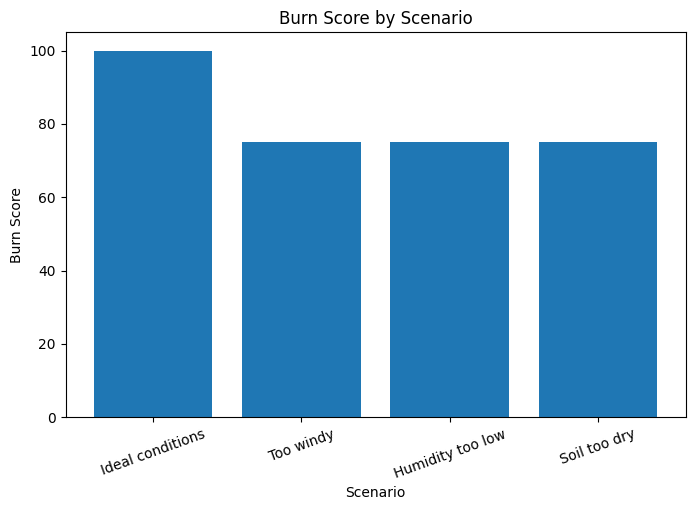

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df["scenario"], df["burn_score"])
plt.ylabel("Burn Score")
plt.xlabel("Scenario")
plt.title("Burn Score by Scenario")
plt.xticks(rotation=20)
plt.show()

## Burn Window Scoring Scenario Tests

This notebook tests the PyroLens rule-based burn scorer under four environmental scenarios:
- Ideal conditions
- Excessive wind
- Very low humidity
- Very dry soil

The scorer combines weighted environmental scoring with hard safety thresholds. This allows the system to return a burn score while still overriding the recommendation when critical conditions are unsafe.